In [1]:
import numpy as np
import pandas as pd
import os, sys
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from typing import Dict, List
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
import h5py
import torch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
def process_array_by_groups(arr, true_token_ids, group_size=3):
    tokenProb = []
    for row, token_id in zip(arr, true_token_ids):
        curToken = tokenizer.convert_ids_to_tokens(int(token_id))
        curProb = row[nucleotides.index(curToken)]
        tokenProb.append(curProb)
    
    avg_tokenProb = [np.mean(tokenProb[i:i+group_size]) for i in range(0, len(tokenProb), group_size)]
    return avg_tokenProb

def create_binary_labels(label):
    return 1 if label == "Core Gene" else 0

def chunks(lst, n):
    return [''.join(lst[i:i+n]).upper() for i in range(0, len(lst), n)]
    
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [4]:
LOGIT_PATHS = get_file_paths('pcv2_1', '../../../results/Lloyd_2015_essential_genes/plantcad2_logits/')
LABEL_PATHS = get_file_paths('labels', '../../../results/Lloyd_2015_essential_genes/zero_shot_input/')

In [5]:
JUNCTIONS

['start_sites', 'stop_sites', 'donor', 'acceptor']

In [6]:
labels_dict = {}
nucleotides = list('acgt')
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(LABEL_PATHS[junction], sep='\t')
    
    # load plantcad2 logits
    with h5py.File(LOGIT_PATHS[junction], 'a') as hf:
        plantcad2_logits = torch.tensor(hf['predicted_logits'][:])
        true_ids = torch.tensor(hf['true_token_ids'][:])

    plantcad2_logits = plantcad2_logits[:, [tokenizer.get_vocab()[nc] for nc in nucleotides]] # only retain atcg
    plantcad2_logits = torch.tensor(plantcad2_logits)
    plantcad2_probs = torch.nn.functional.softmax(plantcad2_logits, dim=1).numpy()

    # load evo2 logits
    # loaded = np.load(fnames_evo2[idx])
    # evo_probs = loaded['logits']
    # evo_probs_reshaped = evo_probs.reshape(-1, 4)
    
    if junction in ['start_sites', 'stop_sites']:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=3)
        # evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=3)
    else:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=2)
        # evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=2)

    label['predicted_plantcad2'] = plantcad2_scores
    label['transcript'] = label['Name'].str.replace('transcript:', '').str.split('_', expand=True)[0]
    # label['predicted_evo2'] = evo2_scores
    labels_dict[junction] = label

/tmp/ipykernel_4136402/2525140242.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_4136402/2525140242.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_4136402/2525140242.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_4136402/2525140242.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().

In [7]:
donor_collapse = labels_dict['donor'].groupby('transcript')[['predicted_plantcad2']].mean()
acceptor_collapse  = labels_dict['acceptor'].groupby('transcript')[['predicted_plantcad2']].mean()

In [8]:
donor_collapse.shape, acceptor_collapse.shape, labels_dict['start_sites'].shape, labels_dict['stop_sites'].shape

((6250, 1), (6250, 1), (6628, 4), (6627, 4))

In [9]:
donor_collapse = donor_collapse.rename(columns={
    'predicted_plantcad2': 'predicted_plantcad2_donor',
})

acceptor_collapse = acceptor_collapse.rename(columns={
    'predicted_plantcad2': 'predicted_plantcad2_acceptor',
})

# Then merge
merged_df = labels_dict['start_sites'].merge(
    labels_dict['stop_sites'], 
    on='transcript', 
    how='left'
).merge(
    donor_collapse, 
    on='transcript', 
    how='left'
).merge(
    acceptor_collapse, 
    on='transcript', 
    how='left'
)

In [10]:
plantcad2_scores = merged_df[['predicted_plantcad2_x', 'predicted_plantcad2_y', 'predicted_plantcad2_donor', 'predicted_plantcad2_acceptor']].sum(axis=1)
# evo2_scores = merged_df[['predicted_evo2_x', 'predicted_evo2_y', 'predicted_evo2_donor', 'predicted_evo2_acceptor']].mean(axis=1)

In [11]:
merged_df['plantcad2_scores'] = plantcad2_scores
# merged_df['evo2_scores'] = evo2_scores

In [12]:
merged_df.head()

,Name_x,Label_x,predicted_plantcad2_x,transcript,Name_y,Label_y,predicted_plantcad2_y,predicted_plantcad2_donor,predicted_plantcad2_acceptor,plantcad2_scores
0,transcript:AT1G01030.2_1_8843_17034_-,0,0.404892,AT1G01030.2,transcript:AT1G01030.2_1_7769_15960_-,0.0,0.563212,0.358760,0.504821,1.831685
1,transcript:AT1G01030.1_1_8843_17034_-,0,0.404892,AT1G01030.1,transcript:AT1G01030.1_1_7769_15960_-,0.0,0.563212,0.297709,0.547721,1.813534
2,transcript:AT1G01040.1_1_19425_27616_+,1,0.313086,AT1G01040.1,transcript:AT1G01040.1_1_26983_35174_+,1.0,0.707951,0.934764,0.958261,2.914062
3,transcript:AT1G01040.2_1_19425_27616_+,1,0.313086,AT1G01040.2,transcript:AT1G01040.2_1_26983_35174_+,1.0,0.707951,0.894408,0.958261,2.873706
4,transcript:AT1G01060.6_1_32739_40930_-,0,0.946944,AT1G01060.6,transcript:AT1G01060.6_1_29897_38088_-,0.0,0.210931,0.745310,0.580651,2.483836


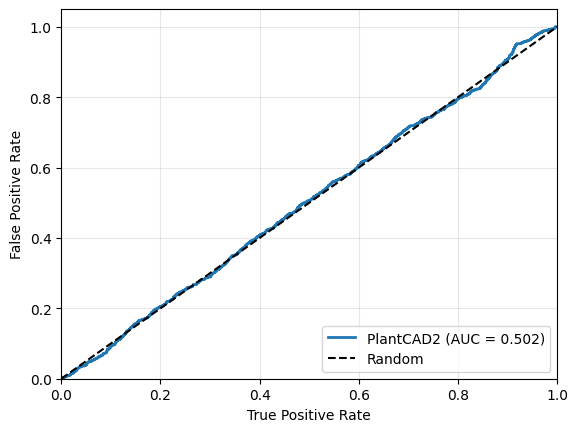

In [13]:

y_true = merged_df['Label_x'].values
y_scores_cad2 = merged_df['plantcad2_scores'].values
# y_scores_evo2 = subsets['evo2_scores'].values

fpr_cad2, tpr_cad2, _ = roc_curve(y_true, y_scores_cad2)
# fpr_evo2, tpr_evo2, _ = roc_curve(y_true, y_scores_evo2)

roc_auc_cad2 = auc(fpr_cad2, tpr_cad2)
# roc_auc_evo2 = auc(fpr_evo2, tpr_evo2)

plt.plot(fpr_cad2, tpr_cad2, 
       label=f'PlantCAD2 (AUC = {roc_auc_cad2:.3f})',
       color='C0', linewidth = 2)
# plt.plot(fpr_evo2, tpr_evo2, 
#        label=f'EVO2 (AUC = {roc_auc_evo2:.3f})',
#        color='C1', linewidth = 2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
# plt.savefig('../../pipelines/pseudo_gene/Core_noncore_gene_classification.pdf', format='pdf',bbox_inches='tight')
plt.show()